<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/Binarry_Classification(Neural_Network).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install torchinfo

In [3]:
import os
import sys
from collections import Counter

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchvision
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
from tqdm.version import __version__ as tqdm__version__

torch.backends.cudnn.deterministic = True

In [4]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("CV2 version : ", cv2.__version__)
print("matplotlib version : ", matplotlib.__version__)
print("numpy version : ", np.__version__)
print("torch version : ", torch.__version__)
print("torchinfo version : ", torchinfo.__version__)
print("torchvision version : ", torchvision.__version__)
print("PIL version : ", PIL.__version__)
print("scikit-learn version: ", sklearn.__version__)
print("tqdm version: ", tqdm__version__)

Platform: linux
Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
---
CV2 version :  4.11.0
matplotlib version :  3.10.0
numpy version :  2.0.2
torch version :  2.6.0+cu124
torchinfo version :  1.8.0
torchvision version :  0.21.0+cu124
PIL version :  11.2.1
scikit-learn version:  1.6.1
tqdm version:  4.67.1


In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


In [6]:

!gcloud auth login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=Khrv7oYPjRw5LV7u1Oky9cepd9GlLr&prompt=consent&token_usage=remote&access_type=offline&code_challenge=8XCZfKO1uSWWGTCTS5Fb844XVMMqrUE2kuja3d9v85s&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AUJR-x7KiackmsVkqVHpYsZiAYBgWi3W2VPg5gznKVjT7e3RrthZCuCCxKMvVWfV2mhB_Q

You are now logged in as [lekanggy12@gmail.com].
Your current project i

In [7]:
!gcloud storage ls gs://wqu-cv-course-datasets

gs://wqu-cv-course-datasets/OLD_vanilla_gan.tar.gz
gs://wqu-cv-course-datasets/dhaka_traffic.mp4
gs://wqu-cv-course-datasets/lupita_nyongo.mp4
gs://wqu-cv-course-datasets/mary_kom.mp4
gs://wqu-cv-course-datasets/polyp_model.pth
gs://wqu-cv-course-datasets/project1.tar.gz
gs://wqu-cv-course-datasets/project1assignment.tgz
gs://wqu-cv-course-datasets/project2.tar.gz
gs://wqu-cv-course-datasets/project2assignment.tar.gz
gs://wqu-cv-course-datasets/project3.tar.gz
gs://wqu-cv-course-datasets/project3_video.tar.gz
gs://wqu-cv-course-datasets/project3assignment.tar.gz
gs://wqu-cv-course-datasets/project4_video.tar.gz
gs://wqu-cv-course-datasets/project5.tar.gz
gs://wqu-cv-course-datasets/project5_models.tar.gz
gs://wqu-cv-course-datasets/project5_vanilla_models.tar
gs://wqu-cv-course-datasets/project6_images.tar.gz
gs://wqu-cv-course-datasets/vanilla_gan.tar.gz


In [8]:
!gcloud storage cp gs://wqu-cv-course-datasets/project1.tar.gz . --no-clobber

Copying gs://wqu-cv-course-datasets/project1.tar.gz to file://./project1.tar.gz

Average throughput: 72.4MiB/s


In [9]:
!tar --skip-old-files -xzvf project1.tar.gz

Streaming output truncated to the last 5000 lines.
./data_p1/data_multiclass/train/antelope_duiker/ZJ004383.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ006594.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ007846.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ006580.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ000697.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ013402.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ003611.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ005260.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ002269.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ004618.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ010679.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ015701.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ011201.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ002533.jpg
./data_p1/data_multiclass/train/antelope_duiker/ZJ002255.jpg
./data_p1/data_multiclass/train/an

In [10]:
data_dir = os.path.join("data_p1", "data_binary")
train_dir = os.path.join(data_dir, "train")

print("Data Directory:", data_dir)
print("Training Data Directory:", train_dir)

Data Directory: data_p1/data_binary
Training Data Directory: data_p1/data_binary/train


In [11]:
labels = os.listdir(train_dir)
print(labels)

['hog', 'blank']


In [12]:
hog_path = os.path.join(train_dir, "hog")
hog_images = os.listdir(hog_path)
print("length of hog images: ", len(hog_images))

blank_path = os.path.join(train_dir, "blank")
blank_images = os.listdir(blank_path)
print("length of blank images: ", len(blank_images))


length of hog images:  978
length of blank images:  2213


In [13]:
hog_image_name = hog_images[0]
print(hog_image_name)

hog_image_path = os.path.join(hog_path, hog_image_name)
print(hog_image_path)

blank_image_name = blank_images[0]
print(blank_image_name)

blank_image_path = os.path.join(blank_path, blank_image_name)
print(blank_image_path)

ZJ011972.jpg
data_p1/data_binary/train/hog/ZJ011972.jpg
ZJ006781.jpg
data_p1/data_binary/train/blank/ZJ006781.jpg


In [14]:
hog_img_pil = Image.open(hog_image_path)
print("Hog image: ", hog_img_pil.mode, hog_img_pil.size)

blank_img_pil = Image.open(blank_image_path)
print("Blank image: ", blank_img_pil.mode, blank_img_pil.size)

Hog image:  RGB (640, 360)
Blank image:  RGB (640, 360)


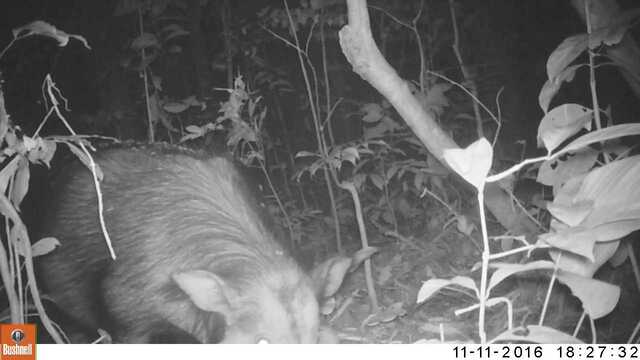

In [20]:
hog_img_pil

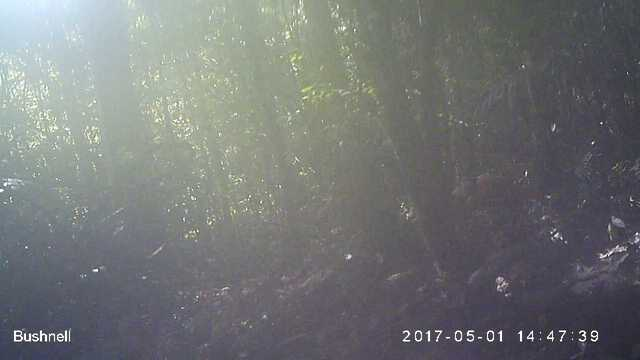

In [21]:
blank_img_pil

In [15]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [16]:
# Define transformation to apply to the images
transform = transforms.Compose(
    [
        ConvertToRGB(),  # Convert images to RGB format if not already
        transforms.Resize((224, 224)),  # Resize images to 224x224
        transforms.ToTensor()

    ]
)

print(type(transform))
print(transform)

<class 'torchvision.transforms.transforms.Compose'>
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [17]:
dataset = datasets.ImageFolder(root=train_dir, transform=transform)
print(type(dataset))

<class 'torchvision.datasets.folder.ImageFolder'>


In [18]:
#Print th classes
dataset.classes

['blank', 'hog']

In [19]:
im = dataset.imgs
print(im[0])

distinct_classes = {x[1] for x in im}
print(distinct_classes)

('data_p1/data_binary/train/blank/ZJ000013.jpg', 0)
{0, 1}


In [20]:
# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)

train_dataset, val_dataset = random_split(dataset, [0.8, 0.2], generator=g)

In [21]:
print(f"Length of training set: {len(train_dataset)}")
print(f"Length of validation set: {len(val_dataset)}")

Length of training set: 2553
Length of validation set: 638


In [22]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [23]:
train_counts = class_counts(train_dataset)
train_counts

  0%|          | 0/2553 [00:00<?, ?it/s]

,0
blank,1749
hog,804


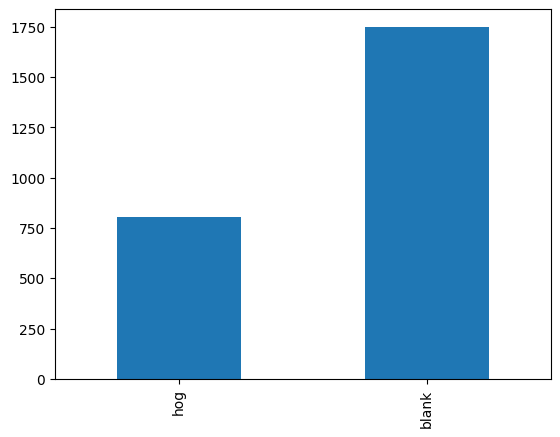

In [24]:
train_counts.sort_values().plot(kind="bar");

In [25]:
val_counts = class_counts(val_dataset)
val_counts

  0%|          | 0/638 [00:00<?, ?it/s]

,0
blank,464
hog,174


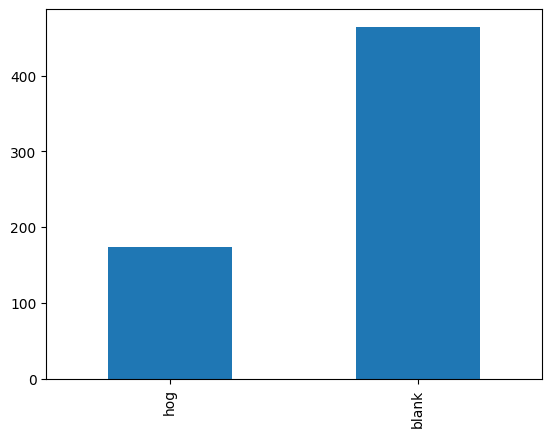

In [26]:
val_counts.sort_values().plot(kind="bar");

In [27]:
# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(type(val_loader))

<class 'torch.utils.data.dataloader.DataLoader'>
